In [1]:
import pandas as pd
df = pd.read_csv('cleaned_lte_qos_dataset.csv')


In [2]:
drop_cols = [

    'QoS',

    'DL_bitrate',
    'UL_bitrate',

    'NetworkMode',

    'CellID',

    'RSSI',

    'Longitude',
    'Latitude',

    'ServingCell_Lon',
    'ServingCell_Lat',

    'Month'
]

X = df.drop(columns=drop_cols)
y = df['QoS']

In [3]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [12]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# ==========================================
# APPLY SMOTE FOR RANDOM FOREST
# ==========================================

from imblearn.over_sampling import SMOTE

# ------------------------------------------
# Create SMOTE object
# ------------------------------------------

smote = SMOTE(
    random_state=42
)

# ------------------------------------------
# Apply ONLY on training data
# ------------------------------------------

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# ------------------------------------------
# Check new class distribution
# ------------------------------------------

print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_smote.value_counts())

QoS
0    61609
1    31989
2     2646
Name: count, dtype: int64

After SMOTE:

QoS
0    61609
1    61609
2    61609
Name: count, dtype: int64


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    min_samples_split=5,
    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)

model.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring='f1_macro'
)

print(scores)

print("Mean:", scores.mean())

[0.99004343 0.98896081 0.98904051 0.98982599 0.9891491 ]
Mean: 0.9894039684754412


In [20]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     15465
           1       0.95      0.99      0.97      7931
           2       0.91      1.00      0.95       665

    accuracy                           0.98     24061
   macro avg       0.96      0.99      0.97     24061
weighted avg       0.98      0.98      0.98     24061

[[15067   389     9]
 [    0  7876    55]
 [    0     0   665]]
Accuracy: 0.9811728523336519


In [22]:

import joblib


joblib.dump(model, "random_forest_best.pkl")

['random_forest_best.pkl']

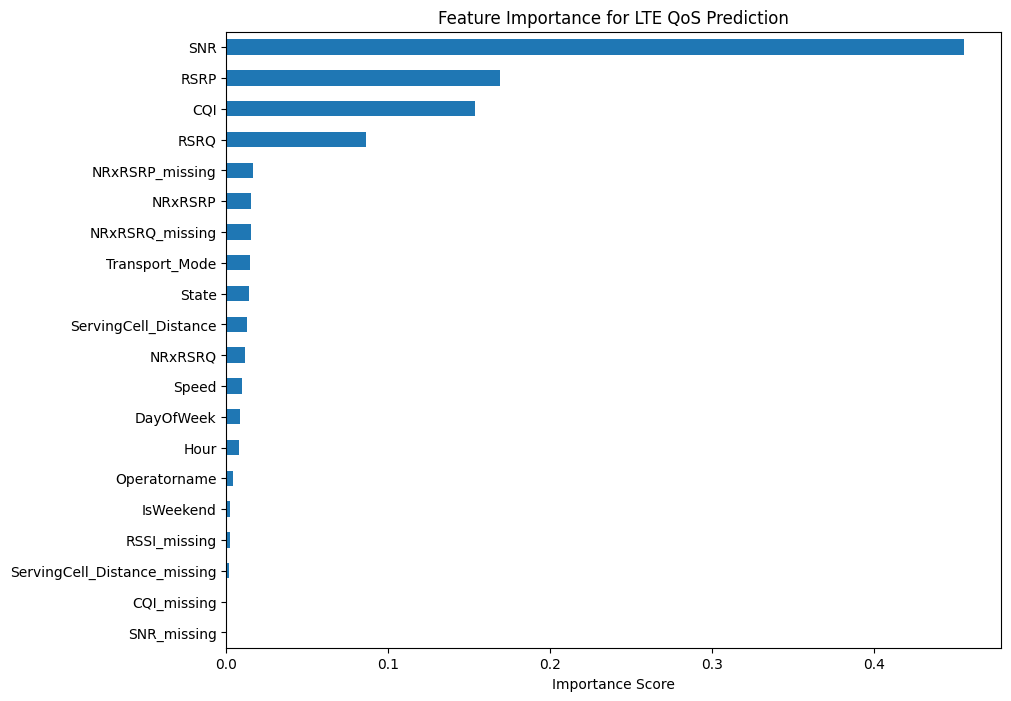

In [18]:
import matplotlib.pyplot as plt

feat_imp.sort_values().plot(
    kind='barh',
    figsize=(10,8)
)

plt.title("Feature Importance for LTE QoS Prediction")

plt.xlabel("Importance Score")

plt.show()

In [4]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "call_drop_feature_columns.pkl"
)

print("Saved", len(feature_columns), "features")

Saved 20 features


In [7]:
import joblib

cols = joblib.load("qos_feature_columns.pkl")

print("Number of features:", len(cols))

for c in cols:
    print(c)

Number of features: 20
Speed
Operatorname
RSRP
RSRQ
SNR
CQI
State
NRxRSRP
NRxRSRQ
ServingCell_Distance
Transport_Mode
SNR_missing
CQI_missing
RSSI_missing
NRxRSRP_missing
NRxRSRQ_missing
ServingCell_Distance_missing
Hour
DayOfWeek
IsWeekend
